In [1]:
import pandas as pd
from datetime import datetime
import numpy as np

# Input data
congestion_data = {
    "Indonesia": [
        [0,0,0,0,0,0,0,0,0,8,12,16,22,26,27,28,28,27,25,22,19,16,10,0],
        [0,0,0,0,0,0,13,36,55,48,43,42,41,42,45,48,57,82,83,58,24,12,5,0],
        [0,0,0,0,0,0,12,36,57,55,52,51,53,55,59,61,70,96,101,75,34,19,11,0],
        [0,0,0,0,0,0,12,36,57,55,52,53,55,58,62,64,74,101,104,79,40,25,16,0],
        [0,0,0,0,0,0,10,33,53,50,50,53,56,58,62,65,72,96,96,70,34,22,14,0],
        [0,0,0,0,0,0,11,31,45,40,43,47,35,54,67,69,73,99,103,81,46,37,33,9],
        [0,0,0,0,0,0,0,0,5,13,24,34,42,50,55,59,61,59,54,44,34,39,41,15]
    ],
    "Thailand": [
        [0,0,0,0,0,0,0,2,8,14,22,31,38,39,40,43,45,45,38,32,26,19,12,1],
        [0,0,0,0,0,0,36,68,66,54,46,42,42,41,45,52,65,81,76,51,27,15,8,0],
        [0,0,0,0,0,1,37,72,76,70,62,57,54,52,55,65,82,104,101,72,40,22,12,2],
        [0,0,0,0,0,1,37,71,74,66,60,57,55,53,57,66,83,103,98,68,38,22,13,1],
        [0,0,0,0,0,1,37,70,72,65,59,55,54,54,58,68,86,106,101,71,41,24,15,3],
        [0,0,0,0,0,0,34,64,60,53,52,54,58,61,69,84,104,123,112,77,49,32,25,10],
        [1,0,0,0,0,0,0,9,20,32,44,55,67,67,66,68,72,74,60,42,32,26,22,8]
    ],
    "Malaysia": [
        [6,0,0,0,0,0,0,0,0,1,6,13,20,21,23,25,22,21,23,19,18,18,17,3],
        [0,0,0,0,0,0,7,39,53,30,15,15,21,22,22,24,30,52,65,38,14,8,6,0],
        [0,0,0,0,0,0,8,43,61,42,24,21,25,25,26,27,34,61,77,50,21,10,8,0],
        [0,0,0,0,0,0,7,43,62,43,25,21,27,25,26,28,37,64,84,56,25,13,10,0],
        [0,0,0,0,0,0,6,39,55,36,22,21,27,26,27,29,35,61,80,55,24,14,12,0],
        [0,0,0,0,0,0,6,31,36,23,19,22,38,30,33,36,42,69,80,55,31,25,29,13],
        [1,0,0,0,0,0,0,0,1,10,18,26,36,40,41,43,40,39,42,36,28,29,38,22]
    ],
    "Philippines": [
        [3,0,0,0,0,0,0,1,5,9,14,19,21,22,28,34,35,35,34,27,21,21,17,2],
        [0,0,0,0,0,4,29,51,53,45,43,41,36,37,44,49,59,72,74,50,28,17,10,0],
        [0,0,0,0,0,3,29,55,62,56,55,51,45,47,55,60,71,86,90,64,40,27,17,4],
        [0,0,0,0,0,3,28,53,60,56,56,53,48,50,58,64,75,91,93,67,43,31,22,7],
        [0,0,0,0,0,3,27,51,57,53,54,52,47,49,58,64,74,89,90,64,40,30,23,9],
        [0,0,0,0,0,2,23,42,46,44,50,52,49,52,63,70,80,93,94,67,45,36,33,18],
        [5,0,0,0,0,0,4,11,18,27,36,41,42,45,52,57,60,61,56,40,26,25,29,16]
    ]
}

# in thousands
lkz_2018 = {
    "Indonesia": 106658,
    "Thailand": 39551.79,
    "Malaysia": 29956.47,
    "Philippines": 11595
}

pkw_2018 = {
    "Indonesia": 14831,
    "Thailand": 16498.49,
    "Malaysia": 14191.34,
    "Philippines": 34
}

# Compute weighted congestion
def compute_weighted(congestion_data, weights):
    weighted_array = np.zeros((7, 24))
    total_weight = 0
    for country, data in congestion_data.items():
        weight = weights[country]
        total_weight += weight
        weighted_array += np.array(data) * weight
    return weighted_array / total_weight

# Step 1: Load German patterns
df_kfz = pd.read_csv("KFZ__count", skiprows=2)
#display(df_kfz)
german_counts_lkz = df_kfz["count"].values.reshape((7, 24))
german_min_percent_lkz = (german_counts_lkz.min() / german_counts_lkz.max()) * 100

df_pkw = pd.read_csv("pkw__count", skiprows=2)
german_counts_pkw = df_pkw["count"].values.reshape((7, 24))
german_min_percent_pkw = (german_counts_pkw.min() / german_counts_pkw.max()) * 100


# Step 3: Compute weighted ASEAN values
weighted_congestion_pkw = compute_weighted(congestion_data, pkw_2018)
weighted_congestion_lkz = compute_weighted(congestion_data, lkz_2018)

pkw_2018 = {
    "Brunei Darussalam": 260,
    "Cambodia": 67.42,
    "Indonesia": 14831,
    "Lao PDR": 135.37,
    "Malaysia": 14191.34,
    "Myanmar": 542.73,
    "Philippines": 34,
    "Singapore": 615,
    "Thailand": 16498.49,
    "Viet Nam": 1756.59
}

kfz_2018 = {
    "Brunei Darussalam": 426,
    "Cambodia": 580.9,
    "Indonesia": 106658,
    "Lao PDR": 2105,
    "Malaysia": 29956.47,
    "Myanmar": 7215.5,
    "Philippines": 11595,
    "Singapore": 957,
    "Thailand": 39551.79,
    "Viet Nam": 3274.37
}


count_pkw = sum(pkw_2018.values())
count_lkz = sum(lkz_2018.values())

def fill_asean_zeros_scaled_by_mean(asean_array, german_counts_array):
    asean_array = asean_array.copy()
    german_shape = german_counts_array / german_counts_array.max(axis=1, keepdims=True)*100

    for day in range(7):
        asean_day = asean_array[day]
        german_day = german_shape[day]

        # Scale German shape so its average matches ASEAN daily max
        german_scaled = german_day * (asean_day.max() / german_day.max())
        
        for hour in range(24):
            if asean_day[hour] < 1:
                asean_array[day, hour] = german_scaled[hour]
                print(f"Day {day}: german scaled={german_scaled[hour]:.2f}, german nonscaled ={german_day[hour]:.2f}")
                if 0 < hour < 23:
                    if asean_array[day,hour+1]>1:
                        asean_array[day, hour] = (asean_array[day, hour + 1]+asean_array[day, hour - 1])/2 

        # Optional: Re-normalize so each day maxes at 100
        asean_array[day] = (asean_array[day] / asean_array[day].max()) * 100

        # Debug print
        #print(f"Day {day}: german scale={german_scaled[5]:.2f}, Filled 5AM={asean_array[day,5]:.2f}")

    return asean_array



# Apply zero-filling
weighted_congestion_pkw = fill_asean_zeros_scaled_by_mean(weighted_congestion_pkw, german_counts_pkw)
weighted_congestion_lkz = fill_asean_zeros_scaled_by_mean(weighted_congestion_lkz, german_counts_lkz)
#print("Any zeros left in weighted_congestion_pkw?", (weighted_congestion_pkw == 0).any())
#print("Any zeros left in weighted_congestion_lkz?", (weighted_congestion_lkz == 0).any())


count_pkw_ = weighted_congestion_pkw * count_pkw
count_lkz_ = weighted_congestion_lkz * count_lkz
n_counts_pkw = count_pkw_ / count_pkw
n_counts_lkz = count_lkz_ / count_lkz

# Save PKW
rows = [[day, hour, count_pkw_[day, hour], n_counts_pkw[day, hour]]
        for day in range(7) for hour in range(24)]
df_pkw = pd.DataFrame(rows, columns=["day", "hour", "count", "n_counts"])

from datetime import datetime
import pandas as pd

# Save PKW
header_pkw = f"""File generated for type: PKW_
Time of generation:{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

with open("PKW_ASEAN", "w", newline="") as f:  # newline="" avoids extra blank lines
    f.write(header_pkw)
    df_pkw.to_csv(
        f,
        sep=",",            # must be comma
        index=False,
        header=True,        # this will write 'day,hour,count,n_counts'
        float_format="%.6f"
    )

# Save KFZ (LKZ)
rows = [[day, hour, count_lkz_[day, hour], n_counts_lkz[day, hour]]
        for day in range(7) for hour in range(24)]
df_lkz = pd.DataFrame(rows, columns=["day", "hour", "count", "n_counts"])

header_kfz = f"""File generated for type: KFZ_
Time of generation:{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

with open("KFZ_ASEAN", "w", newline="") as f:
    f.write(header_kfz)
    df_lkz.to_csv(
        f,
        sep=",",
        index=False,
        header=True,
        float_format="%.6f"
    )


Day 0: german scaled=1.82, german nonscaled =5.60
Day 0: german scaled=1.51, german nonscaled =4.65
Day 0: german scaled=1.92, german nonscaled =5.90
Day 0: german scaled=4.02, german nonscaled =12.36
Day 0: german scaled=12.00, german nonscaled =36.93
Day 0: german scaled=23.69, german nonscaled =72.88
Day 0: german scaled=31.41, german nonscaled =96.64
Day 1: german scaled=4.77, german nonscaled =6.37
Day 1: german scaled=2.89, german nonscaled =3.86
Day 1: german scaled=2.27, german nonscaled =3.03
Day 1: german scaled=2.66, german nonscaled =3.55
Day 1: german scaled=5.93, german nonscaled =7.93
Day 1: german scaled=21.99, german nonscaled =29.38
Day 1: german scaled=9.62, german nonscaled =12.85
Day 2: german scaled=6.27, german nonscaled =6.71
Day 2: german scaled=3.66, german nonscaled =3.91
Day 2: german scaled=2.77, german nonscaled =2.97
Day 2: german scaled=3.18, german nonscaled =3.40
Day 2: german scaled=7.00, german nonscaled =7.49
Day 2: german scaled=26.06, german nonsc

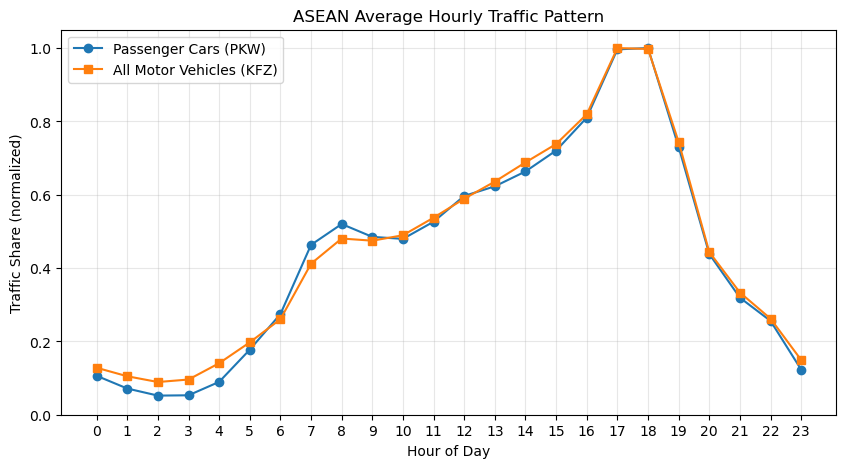

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Assume n_counts_kfz and n_counts_pkw are arrays of shape (7, 24)
# with percentage values (0–100) per hour per day
avg_hourly_kfz = np.mean(weighted_congestion_lkz, axis=0)
avg_hourly_pkw = np.mean(weighted_congestion_pkw, axis=0)

# Normalize so both peak at 1
avg_hourly_kfz /= avg_hourly_kfz.max()
avg_hourly_pkw /= avg_hourly_pkw.max()

# Plotting
plt.figure(figsize=(10,5))
plt.plot(avg_hourly_pkw, label="Passenger Cars (PKW)", marker="o")
plt.plot(avg_hourly_kfz, label="All Motor Vehicles (KFZ)", marker="s")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Share (normalized)")
plt.title("ASEAN Average Hourly Traffic Pattern")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()


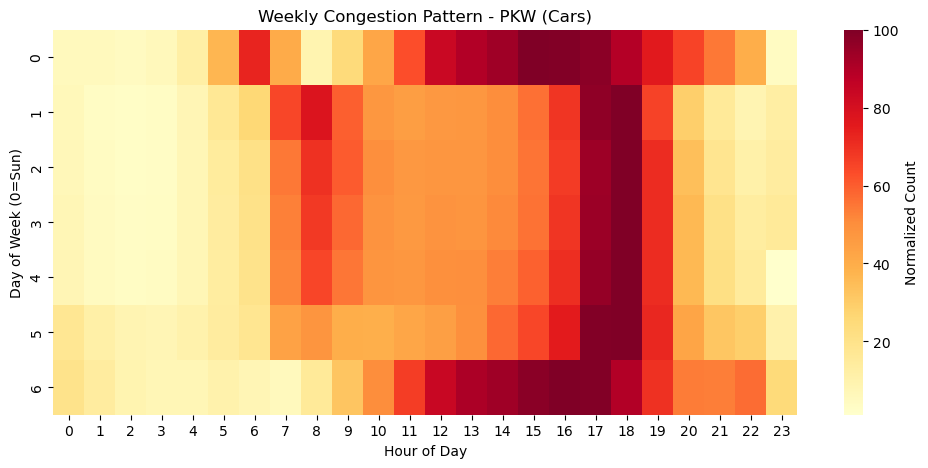

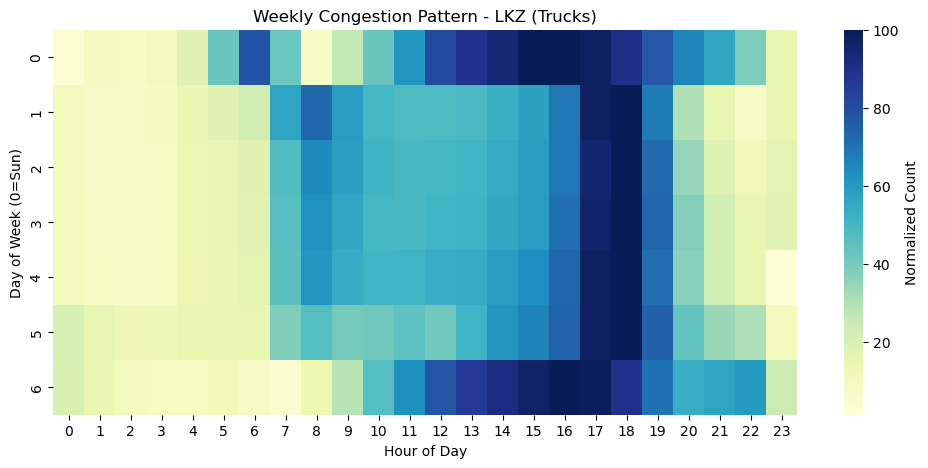

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap for PKW normalized counts
plt.figure(figsize=(12, 5))
sns.heatmap(n_counts_pkw, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Normalized Count'})
plt.title("Weekly Congestion Pattern - PKW (Cars)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Sun)")
plt.show()

# Heatmap for LKZ normalized counts
plt.figure(figsize=(12, 5))
sns.heatmap(n_counts_lkz, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Normalized Count'})
plt.title("Weekly Congestion Pattern - LKZ (Trucks)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Sun)")
plt.show()


In [4]:
n_counts_pkw.max()

100.0

In [5]:
avg_hourly_kfz

array([0.12809009, 0.10488049, 0.08919406, 0.09597922, 0.14051185,
       0.19737317, 0.26046352, 0.4119112 , 0.48055098, 0.47463531,
       0.4894749 , 0.53735025, 0.58913378, 0.63584755, 0.68819468,
       0.73821976, 0.8192893 , 1.        , 0.99759523, 0.74388562,
       0.44363099, 0.33325858, 0.26191344, 0.14926361])

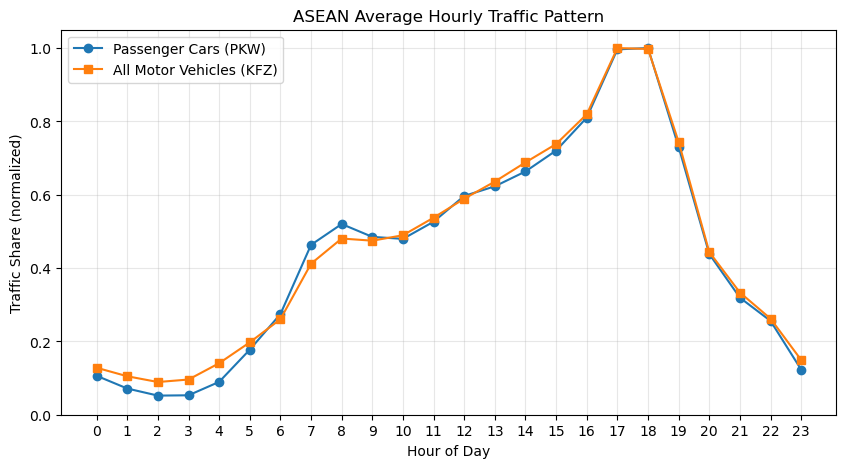

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Assume n_counts_kfz and n_counts_pkw are arrays of shape (7, 24)
# with percentage values (0–100) per hour per day
avg_hourly_kfz = np.mean(weighted_congestion_lkz, axis=0)
avg_hourly_pkw = np.mean(weighted_congestion_pkw, axis=0)

# Normalize so both peak at 1
avg_hourly_kfz /= avg_hourly_kfz.max()
avg_hourly_pkw /= avg_hourly_pkw.max()

# Plotting
plt.figure(figsize=(10,5))
plt.plot(avg_hourly_pkw, label="Passenger Cars (PKW)", marker="o")
plt.plot(avg_hourly_kfz, label="All Motor Vehicles (KFZ)", marker="s")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Share (normalized)")
plt.title("ASEAN Average Hourly Traffic Pattern")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()


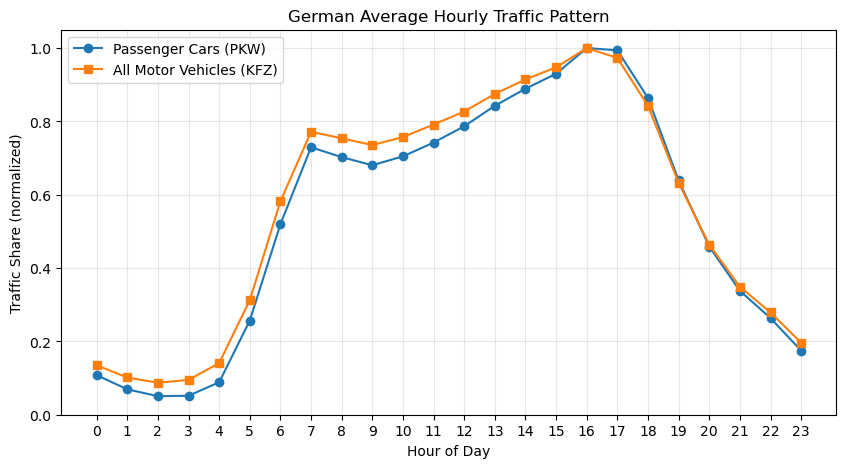

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read German data (skip headers)
df_pkw_germany = pd.read_csv("Pkw__count", skiprows=2)
df_kfz_germany = pd.read_csv("KFZ__count", skiprows=2)

# Reshape count column to 7 days × 24 hours
pkw_count = df_pkw_germany["count"].values.reshape(7, 24)
kfz_count = df_kfz_germany["count"].values.reshape(7, 24)

# Compute average per hour across all days
avg_pkw = pkw_count.mean(axis=0)
avg_kfz = kfz_count.mean(axis=0)

# Normalize to [0, 1]
avg_pkw /= avg_pkw.max()
avg_kfz /= avg_kfz.max()

# Plotting
plt.figure(figsize=(10,5))
plt.plot(avg_pkw, label="Passenger Cars (PKW)", marker="o")
plt.plot(avg_kfz, label="All Motor Vehicles (KFZ)", marker="s")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Share (normalized)")
plt.title("German Average Hourly Traffic Pattern")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()


In [8]:
pkw_count.min()

20734849.0